# Projeto 2 - Jacobi e Gauss-Seidel

Modelo de entrega.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 1a: Implementação

Implemente os métodos de Jacobi e Gauss-Seidel para resolver o sistema linear $Ax = b$.

In [28]:
# Código
using LinearAlgebra
using Plots
using Random
Random.seed!(42)
nothing

In [29]:
function produtorio_sem_i(v::AbstractArray, u::Vector, pos)
    return v' * u - v[pos] * u[pos]
end

function norma(v::Vector)
    return sqrt(v' * v)
end
nothing

In [30]:
function raio_espectral(A::Matrix)
    return maximum(abs.(eigvals(A)))    
end
nothing

In [31]:
function JacobiMatrix(A::Matrix)
    D = Diagonal(diag(A))

    Mj = -D \ (A - D)

    return Mj
end

function JacobiConverge(A::Matrix)
    return norm(JacobiMatrix(A), Inf)
end

nothing

In [32]:
function novo_chute_jacobi!(A::Matrix, v::Vector, cur::Vector, chute::Vector, pos::Int)
    chute[pos] = (v[pos] - produtorio_sem_i(@views(A[pos, :]), cur, pos)) / A[pos, pos]
end

function Jacobi(A::Matrix, v::Vector, eps)
    chute::Vector = zeros(size(v,1))
    cur::Vector = copy(chute)
    m, n = size(A)
    erros = Float64[]

    for _ in 1:1000
        for i in 1:m
            novo_chute_jacobi!(A, v, cur, chute, i)
        end
        push!(erros, norma(A * chute - v))
        if erros[end] < eps
            return chute, erros
        end
        cur = copy(chute)
    end
    return chute, erros
end

nothing

In [33]:
function GaussSeidelMatrix(A::Matrix)
    LD = tril(A)

    Mgs = - LD \ (A - LD)

    return Mgs
end

function GaussSeidelConverge(A::Matrix)
    return norm(GaussSeidelMatrix(A), Inf)
end

nothing

In [34]:
function novo_chute_gs!(A::Matrix, v::Vector, chute::Vector, pos::Int)
    chute[pos] = (v[pos] - produtorio_sem_i(@views(A[pos, :]), chute, pos)) / A[pos, pos]
end

function GaussSiedel(A::Matrix, v::Vector, eps)
    chute::Vector = zeros(size(v,1))
    m, n = size(A)
    erros = Float64[]

    for _ in 1:1000
        for i in 1:m
            novo_chute_gs!(A, v, chute, i)
        end
        push!(erros, norma(A * chute - v))
        if erros[end] < eps
            return chute, erros
        end
    end
    return chute, erros
end

nothing

Qual deveria ser a complexidade computacional do código que você escreveu?

O($n^2$)


## Questão 1b: Testes
Teste com matrizes $2 \times 2$ e $3 \times 3$, e compare graficamente a velocidade de convergência dos dois métodos.

In [35]:
function grafico(JE::Vector, GsE::Vector)
    plot(1:length(JE), JE, marker=:circle, label="Jacobi", xlabel="Iteração", ylabel="Erro", yaxis=:log)
    plot!(1:length(GsE), GsE, marker=:diamond, label="Gauss-Seidel", yaxis=:log)
end

function graficoseparado(v::Vector, l)
    plot(1:length(v), v, marker=:circle, label=l, xlabel="Iteração", ylabel="Erro", yaxis=:log)
end

nothing

In [36]:
function test_matrix_separado(A::Matrix, v::Vector, f, l)
    _, u = f(A, v, 10^(-12))
    graficoseparado(u, l)
end

function test_matrix(A::Matrix, v::Vector)
    J, JE   = Jacobi(A, v, 10^(-12))
    Gs, GsE = GaussSiedel(A, v, 10^(-12))
    
    grafico(JE, GsE)
end

function test_random_matrix(m::Int)
    A = rand(m,m) + 500* I(m)
    v = rand(m)
    
    test_matrix(A, v)
end

nothing

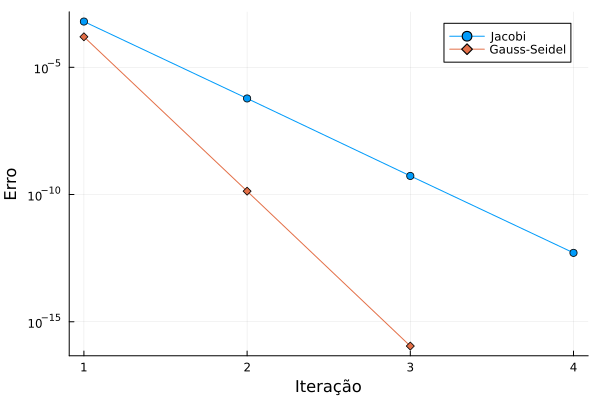

In [37]:
test_random_matrix(2)

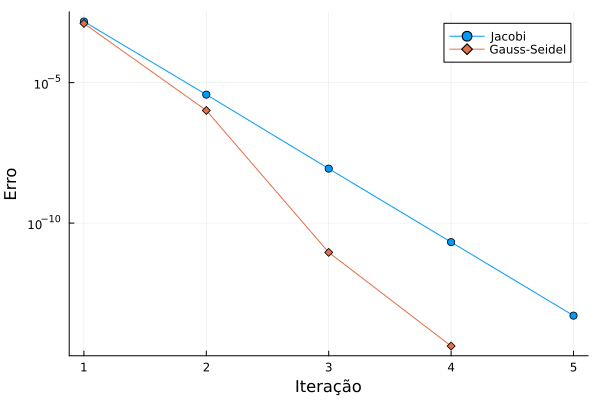

In [38]:
test_random_matrix(3)

Gauss converge mais rápido geralmente

## Questão 1c: Matrizes maiores
Teste com matrizes maiores.  Estes métodos funcionam para matrizes do tipo `rand(m,m)`?

In [39]:
function testar_se_matriz_converge(A::Matrix)
    J = true #JacobiConverge(A) < 1
    Gs = GaussSeidelConverge(A) < 1
    return J && Gs
end

function testar_matrizes(f, tamanho::Int)
    d = 0
    for j in 1:500
        if testar_se_matriz_converge(f(tamanho))
            d += 1
        end
    end
    return d / 500
end

nothing

In [40]:
function randomico(m)
    return rand(m,m)
end

for i in 4:20
    println("$i x $i: Funcionou para $(testar_matrizes(randomico, i) * 100)%")
end

4 x 4: Funcionou para 1.4000000000000001%
5 x 5: Funcionou para 1.0%
6 x 6: Funcionou para 0.0%
7 x 7: Funcionou para 0.0%
8 x 8: Funcionou para 0.0%
9 x 9: Funcionou para 0.0%
10 x 10: Funcionou para 0.0%
11 x 11: Funcionou para 0.0%
12 x 12: Funcionou para 0.0%
13 x 13: Funcionou para 0.0%
14 x 14: Funcionou para 0.0%
15 x 15: Funcionou para 0.0%
16 x 16: Funcionou para 0.0%
17 x 17: Funcionou para 0.0%
18 x 18: Funcionou para 0.0%
19 x 19: Funcionou para 0.0%
20 x 20: Funcionou para 0.0%


Majoritariamente não

## Questão 1d: Matrizes maiores ainda!
Quão grande deve ser $k(m)$ para funcionar para 95\% das matrizes do tipo `randn(m,m)` + $ k(m) \cdot I_m$?  Quais velocidades de convergência você observa para este $k(m)$?

In [41]:
function testar_matrizes(f, tamanho::Int, k)
    d = 0
    for j in 1:500
        if testar_se_matriz_converge(f(tamanho, k))
            d += 1
        end
        if j - d > 35
            return d / j
        end
    end
    return d / 500
end

function makerand(m, k)
    return randn(m,m) + k * I(m)
end

nothing

In [ ]:
function encontrar_k()
    valores = Float64[]

    for i in 1:9
        m = 2 ^ i
        println(m)
        a = sqrt(m)/2
        b = m + 10

        for _ in 1:50
            k = (a + b)/2

            valor = testar_matrizes(makerand, m, k)
            if abs(valor - 0.95) < 10.0 ^ (-10)
                break
            end
            if valor > 0.95
                b = k
            else
                a = k
            end
        end

        push!(valores, (a + b)/2)
    end

    return valores
end

nothing

In [43]:
pontos_k = encontrar_k()

for i in 1:9
    println("$(pontos_k[i]), $(sqrt(2^i))")
end

2
4
8
16
32
64
128
256
512
2.8907420197580485, 1.4142135623730951
3.7973436911706813, 2.0
4.543788682729758, 2.8284271247461903
5.1875, 4.0
6.347785482180276, 5.656854249492381
7.486328125, 8.0
9.16227353054618, 11.313708498984761
11.567326545715332, 16.0
14.757973343397737, 22.627416997969522


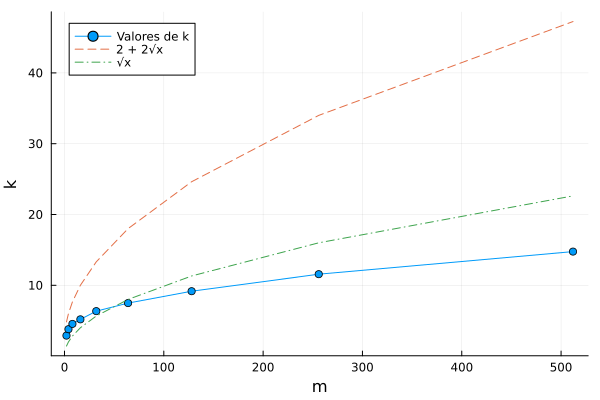

In [44]:
function graficoseparado_linear(v::Vector, l)
    x = 2 .^ (1:length(v))
    plot(x, v, marker=:circle, label=l, xlabel="m", ylabel="k")
    plot!(x, 2.0 .+ 2.0 .* sqrt.(x) , label="2 + 2√x", linestyle=:dash)
    plot!(x, sqrt.(x), label="√x", linestyle=:dashdot)
end

graficoseparado_linear(pontos_k, "Valores de k")

In [45]:
# function k_inf(m)
#     return sqrt(m - 1)
# end

# function k_sup(m)
#     return 2 * sqrt(m - 1)
# end

# function makerand_inf(m)
#     return randn(m,m) + k_inf(m) * I(m)
# end

# function makerand_sup(m)
#     return randn(m,m) + k_sup(m) * I(m)
# end

# println("Cota inferior")
# for i in 1:10
#     println("$i: $(testar_matrizes(makerand_inf, 2^i) * 100)%")
# end

# println("Cota superior")
# for i in 1:10
#     println("$i: $(testar_matrizes(makerand_sup, 2^i) * 100)%")
# end

nothing

(Comentários)

## Questão 1e: Jacobi vs Gauss-Seidel
Encontre uma matriz $A$ $4 \times 4$ para a qual o método de Jacobi tenha melhor convergência que o método de Gauss-Seidel.

Para que Jacobi seja mais rápido, é necessário retirar a vanagem que GS tem sobre ele. Logo podemos pensar numa triangular superior. 
Contudo, nessas matrizes ambas convergem muito rápido.

Então podemos pensar em adicionar um pouco de erro, em especial, apenas na ultima linha, fazendo com que as iterações das linhas 1 a 3 não se diferencie do método de Jacobi


In [46]:
A = [   2  1   0   1
        0  2   1   1 
        0  0   2.1 10
        -1 -10 -10 83
    ]
Norm_A = norm(A, 2)
nothing

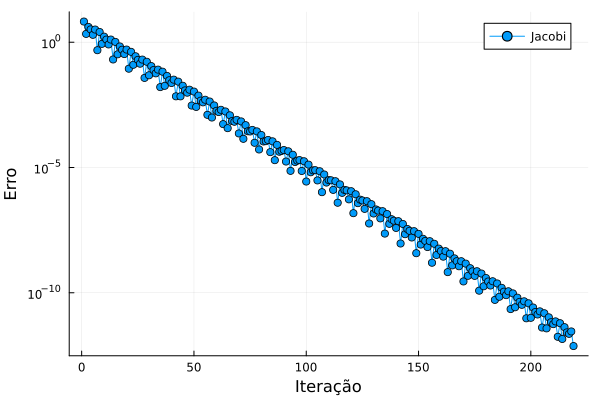

In [47]:
test_matrix_separado(A, rand(4), Jacobi, "Jacobi")

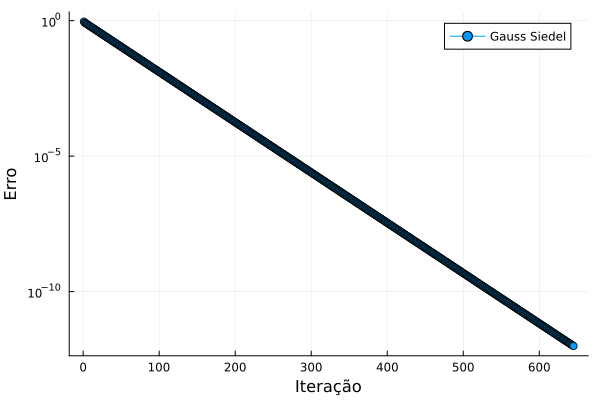

In [48]:
test_matrix_separado(A, rand(4), GaussSiedel, "Gauss Siedel")

## Questão 1f: Perturbações
O que acontece se você somar uma matriz aleatória e pequena à matriz $A$ acima?  O que acontece se esta perturbação acontecer apenas fora da diagonal?

Definição de matriz pequena usada:
$B$ é matriz pequena em relação a $A$ quando $||B|| < ||A|| \times 10^{-2}$

In [49]:
pequena = rand(4,4) * 4 * 10 ^(-1)
println(norm(pequena) / Norm_A)
nA = A + pequena

0.010022417001788561


4×4 Matrix{Float64}:
  2.22698    1.25779    0.2474    1.01853
  0.298472   2.09189    1.19123   1.0486
  0.135935   0.313639   2.48548  10.1217
 -0.843083  -9.75267   -9.96968  83.2023

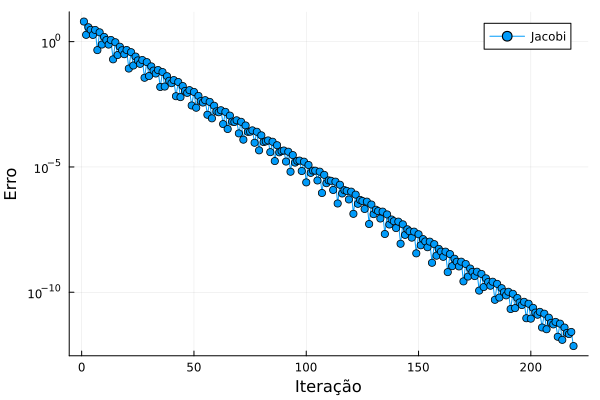

In [50]:

test_matrix_separado(A, rand(4), Jacobi, "Jacobi")

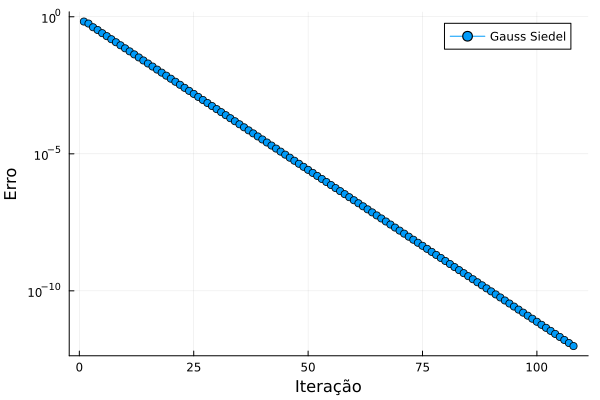

In [51]:
test_matrix_separado(nA, rand(4), GaussSiedel, "Gauss Siedel")

In [52]:
pequenasemdiag = rand(4,4)
pequenasemdiag .-= diag(pequenasemdiag)
println(norm(pequenasemdiag, 2) / Norm_A)

nA2 = A + pequenasemdiag

0.01687237999964872


4×4 Matrix{Float64}:
  2.0         0.697726   -0.329951   1.53435
 -0.619307    2.0         0.523005   0.963329
  0.583602    0.535873    2.1       10.1203
 -1.27336   -10.4574    -10.1647    83.0

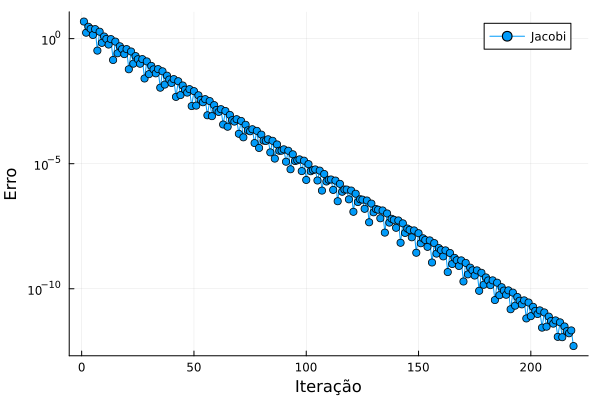

In [53]:
test_matrix_separado(A, rand(4), Jacobi, "Jacobi")

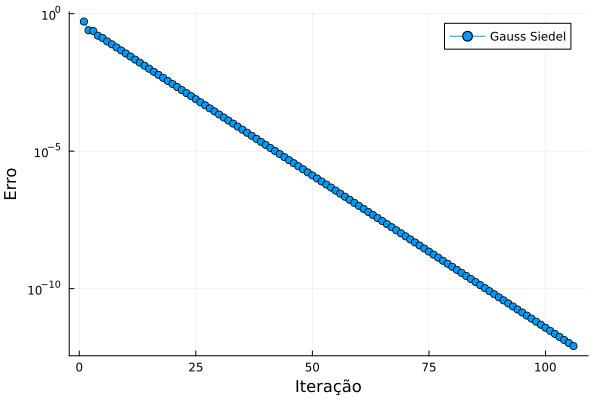

In [54]:
test_matrix_separado(nA, rand(4), GaussSiedel, "Gauss Siedel")

Apesar da pequena mudança, Gauss-Siedel converge mais rápido.